# Pezullo scRNA-seq — RNA vs protein concordance (second validation dataset)

**Dataset:** Pezullo et al., GSE229202 — human bronchial epithelial ALI cultures, IL-13 time course
(baseline / +2 days / +7 days), 10x Genomics 3' scRNA-seq (same lab as the GSE240741 bulk study).

**Purpose:** apply the concordance pipeline built for the Jackson (2020) reference dataset to a
*second, independent* scRNA-seq dataset, and ask whether the same RNA vs protein patterns hold.
In particular the protein-only markers (e.g. **CLCA2**).

The protein layer is my lab's **low-input DIA proteomics of FACS-sorted airway epithelial populations
(~500 cells/well)** — goblet, club (secretory) and multiciliated (MCCs), treated +/- IL-13. These are
*not* single-cell proteomes; each protein value is a mini-bulk population average.

### Two caveats of this integration + analysis

**1. No biological replicates.** Pezullo provide a single culture per timepoint. A replicated pseudobulk
DESeq2 (the correct DE test) is therefore impossible. RNA "significance" here is a **cell-level Wilcoxon
test** (each cell treated as a replicate), written into a DESeq2-shaped CSV only so the *same* pipeline
code can use it.

**2. Goblet cells are entirely IL-13-emergent.** There are **0 goblet cells at baseline** and ~1200 after
IL-13 — classic goblet metaplasia. A within-goblet ctrl-vs-IL13 comparison is impossible, so the goblet RNA
baseline is **control club (secretory) cells**.

## 1. Imports and configuration

In [ ]:
# Import packages

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load GSE229202 samples

Three 10x Genomics count matrices were loaded: untreated baseline, 2-day IL-13 and 7-day IL-13. Cells were labelled by time point before the samples were combined.

In [ ]:
samples = {
    "ctrl": (
        "GSM7156658_IL13_baseline_filtered_feature_bc_matrix.h5",
        "Control"
    ),
    "il13_2d": (
        "GSM7156659_IL13_02days_filtered_feature_bc_matrix.h5",
        "IL13"
    ),
    "il13_7d": (
        "GSM7156660_IL13_07days_filtered_feature_bc_matrix.h5",
        "IL13"
    )
}

adata_list = []

for timepoint, (filename, treatment) in samples.items():
    sample = sc.read_10x_h5("input/" + filename)
    sample.var_names_make_unique()
    sample.obs["timepoint"] = timepoint
    sample.obs["treatment"] = treatment

    # add timepoint to barcode so cell IDs remain unique after concatenation
    sample.obs_names = [
        f"{timepoint}_{barcode}"
        for barcode in sample.obs_names
    ]

    adata_list.append(sample)


adata = sc.concat(
    adata_list,
    join="outer"
)

adata.obs["timepoint"] = adata.obs["timepoint"].astype("category")
adata.obs["treatment"] = adata.obs["treatment"].astype("category")


## 3. Quality control

Cells with fewer than 200 detected genes were removed, genes detected in fewer
than three cells were excluded, and cells with >20% mitochondrial counts were
removed. Raw counts were retained in `layers["counts"]` before normalisation.

In [41]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None
)

print("Before filtering:", adata.shape)

print(
    adata.obs.groupby(
        "timepoint",
        observed=True
    )[
        [
            "n_genes_by_counts",
            "total_counts",
            "pct_counts_mt"
        ]
    ].median()
)

Before filtering: (5556, 33538)
           n_genes_by_counts  total_counts  pct_counts_mt
timepoint                                                
ctrl                  4060.5       16747.0       8.165611
il13_2d               3670.5       13889.5       8.935582
il13_7d               3938.5       15972.0       9.095652


In [42]:
# Cell and gene filtering
sc.pp.filter_cells(
    adata,
    min_genes=200
)

sc.pp.filter_genes(
    adata,
    min_cells=3
)

adata = adata[
    adata.obs["pct_counts_mt"] < 20
].copy()

print("After filtering:", adata.shape)
print(adata.obs["timepoint"].value_counts())

After filtering: (5294, 20266)
timepoint
il13_2d    2685
il13_7d    1708
ctrl        901
Name: count, dtype: int64


In [43]:
adata.layers["counts"] = adata.X.copy()

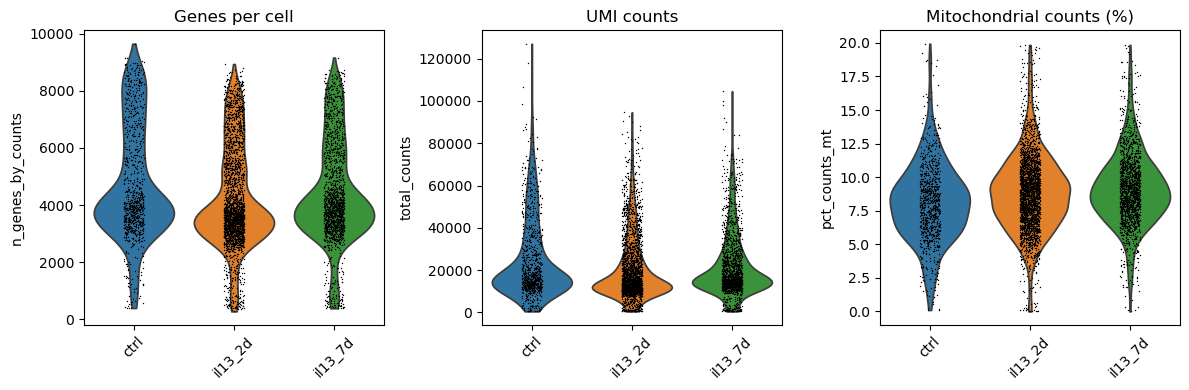

In [44]:
# qc plot
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

qc_metrics = [
    ("n_genes_by_counts", "Genes per cell"),
    ("total_counts", "UMI counts"),
    ("pct_counts_mt", "Mitochondrial counts (%)")
]

for ax, (metric, title) in zip(axes, qc_metrics):

    sc.pl.violin(
        adata,
        metric,
        groupby="timepoint",
        ax=ax,
        show=False,
        rotation=45
    )

    ax.set_title(title)

fig.tight_layout()

fig.savefig(
    RESULTS_DIR / "GSE229202_QC_violin.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 4. Normalisation and dimensionality reduction

Counts were normalised to 10,000 counts per cell and log-transformed. The
2,000 most highly variable genes were used for PCA, neighbour graph
construction, Leiden clustering and UMAP.

In [45]:
# Library-size normalisation
sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

# Log transformation
sc.pp.log1p(adata)

# Keep a copy of the complete log-normalised matrix for expression summaries
# and differential-expression analysis
adata.raw = adata.copy()

In [ ]:
# Identify highly variable genes
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

# Use HVGs only for dimensionality reduction and clustering
adata_hvg = adata[
    :,
    adata.var["highly_variable"]
].copy()

sc.pp.scale(
    adata_hvg,
    max_value=10
)

sc.tl.pca(
    adata_hvg,
    n_comps=30,
    svd_solver="arpack"
)

sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=30
)

sc.tl.leiden(
    adata_hvg,
    resolution=0.5,
    key_added="leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False
)

sc.tl.umap(adata_hvg)

In [47]:
adata.obs["leiden"] = adata_hvg.obs["leiden"]
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]

Visualise clusters

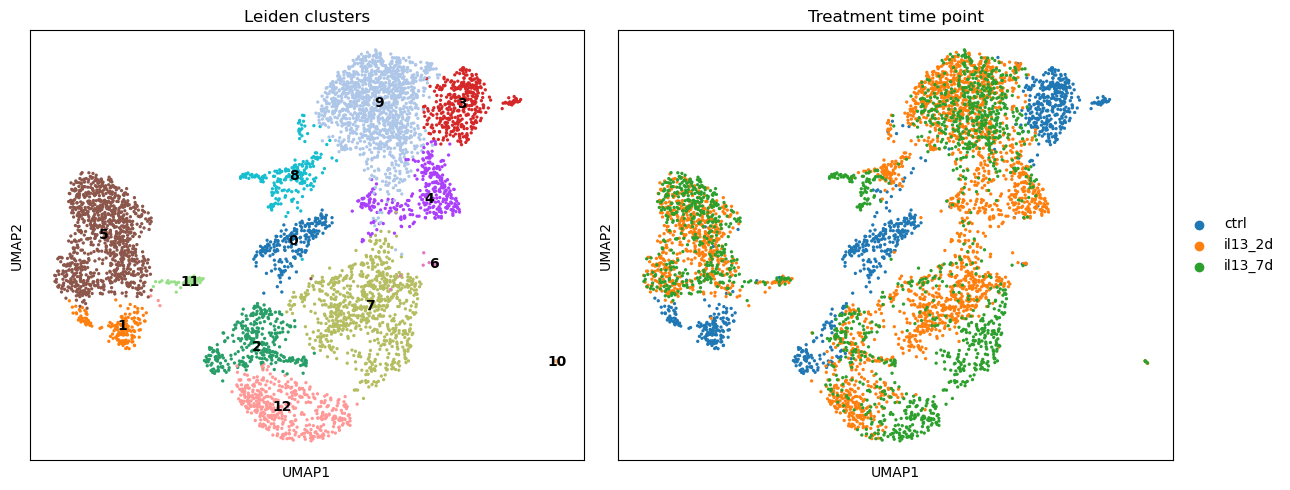

In [49]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sc.pl.umap(
    adata,
    color="leiden",
    ax=axes[0],
    show=False,
    legend_loc="on data",
    title="Leiden clusters"
)

sc.pl.umap(
    adata,
    color="timepoint",
    ax=axes[1],
    show=False,
    title="Treatment time point"
)

fig.tight_layout()

plt.show()

## 5. Airway epithelial cell-type annotation

Clusters were annotated using canonical airway epithelial markers. Marker
scores were calculated for basal, club, goblet and multiciliated programmes,
and cluster-level marker expression was inspected alongside the top
differentially expressed genes for each Leiden cluster.

Secretory clusters were further separated into club and goblet populations
using goblet- and club-associated markers and their treatment composition.

In [50]:
marker_sets = {
    "basal": [
        "KRT5",
        "TP63",
        "NGFR",
        "KRT14",
        "KRT15"
    ],

    "club": [
        "SCGB1A1",
        "SCGB3A1",
        "BPIFB1",
        "SLPI",
        "MSMB"
    ],

    "goblet": [
        "MUC5AC",
        "MUC5B",
        "TSPAN8",
        "TFF3",
        "AGR2"
    ],

    "ciliated": [
        "FOXJ1",
        "DNAH5",
        "CAPS",
        "TSPAN1",
        "PIFO",
        "SNTN"
    ]
}

In [51]:
for cell_type, genes in marker_sets.items():

    present_genes = [
        gene
        for gene in genes
        if gene in adata.raw.var_names
    ]

    sc.tl.score_genes(
        adata,
        present_genes,
        score_name=f"score_{cell_type}",
        use_raw=True
    )


score_columns = [
    f"score_{cell_type}"
    for cell_type in marker_sets
]

cluster_scores = (
    adata.obs
    .groupby(
        "leiden",
        observed=True
    )[score_columns]
    .mean()
)

print(cluster_scores.round(3))

        score_basal  score_club  score_goblet  score_ciliated
leiden                                                       
0            -0.100       2.397        -0.098           0.396
1             0.720       0.610        -0.293          -0.887
2            -0.065       2.353         0.076          -0.660
3            -0.186       0.645        -0.079           1.085
4            -0.156       0.611        -0.044           0.649
5             0.604       0.397        -0.250          -0.904
6             0.056       0.472        -0.034          -0.415
7            -0.157       2.181         0.356           0.361
8            -0.049       1.787         0.342           0.592
9            -0.166       0.563         0.114           0.968
10           -0.152       0.304         0.594          -0.476
11            0.531       0.378        -0.196          -0.886
12           -0.112       2.809         0.522          -0.579


In [52]:
suggested_assignment = (
    cluster_scores
    .idxmax(axis=1)
    .str.replace(
        "score_",
        "",
        regex=False
    )
)

print(suggested_assignment)

leiden
0         club
1        basal
2         club
3     ciliated
4     ciliated
5        basal
6         club
7         club
8         club
9     ciliated
10      goblet
11       basal
12        club
dtype: object


In [53]:
cluster_to_celltype = {
    "1": "basal",
    "5": "basal",
    "11": "basal",

    "0": "club",
    "2": "club",
    "8": "club",

    "7": "goblet",
    "12": "goblet",

    "3": "ciliated",
    "4": "ciliated",
    "9": "ciliated",

    "6": "ionocyte",
    "10": "PNEC"
}

adata.obs["cell_type"] = (
    adata.obs["leiden"]
    .map(cluster_to_celltype)
    .astype("category")
)

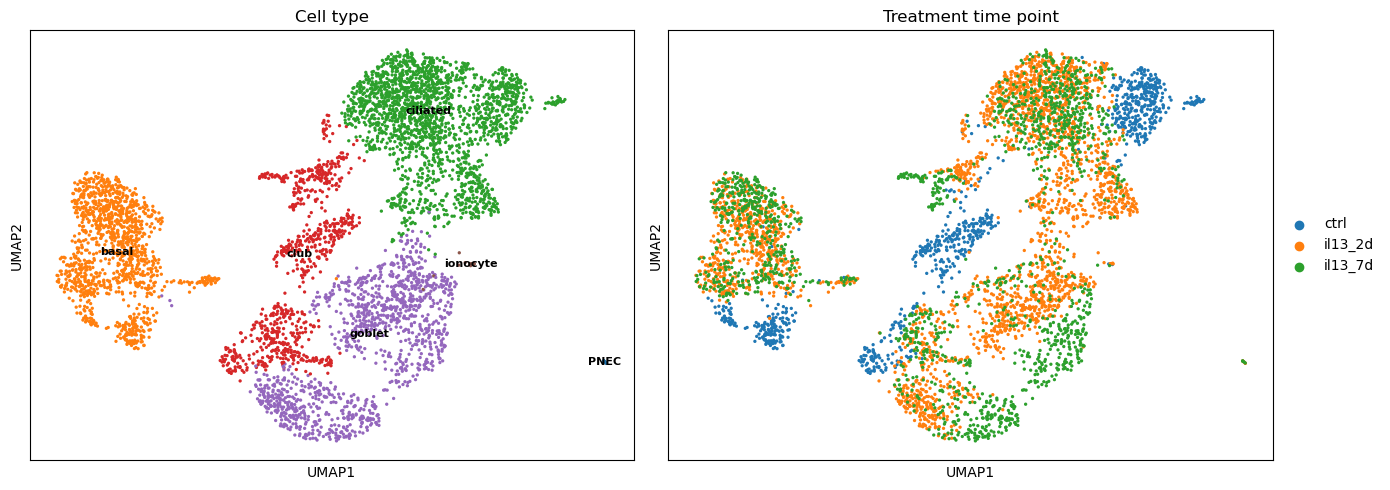

In [54]:
# annotated UMAP

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sc.pl.umap(
    adata,
    color="cell_type",
    ax=axes[0],
    show=False,
    title="Cell type",
    legend_loc="on data",
    legend_fontsize=8
)

sc.pl.umap(
    adata,
    color="timepoint",
    ax=axes[1],
    show=False,
    title="Treatment time point"
)

fig.tight_layout()

plt.show()

## 6. Define control and IL-13 comparison groups

Club and multiciliated cells were compared between the untreated for control sample and the 7-day IL-13 sample.

No goblet population was identified at baseline. Therefore, the goblet comparison uses baseline club/secretory cells as the control secretory population and 7-day IL-13 goblet cells as the treated population. This comparison should not be interpreted as a within-goblet differential- expression analysis.

In [ ]:
comparison_groups = {
    "club": (
        (adata.obs["cell_type"] == "club") &
        (adata.obs["timepoint"] == "ctrl"),

        (adata.obs["cell_type"] == "club") &
        (adata.obs["timepoint"] == "il13_7d")
    ),

    "ciliated": (
        (adata.obs["cell_type"] == "ciliated") &
        (adata.obs["timepoint"] == "ctrl"),

        (adata.obs["cell_type"] == "ciliated") &
        (adata.obs["timepoint"] == "il13_7d")
    ),

    # No baseline goblet population was identified,
    # so baseline club cells are used as the secretory reference
    "goblet": (
        (adata.obs["cell_type"] == "club") &
        (adata.obs["timepoint"] == "ctrl"),

        (adata.obs["cell_type"] == "goblet") &
        (adata.obs["timepoint"] == "il13_7d")
    )
}

In [56]:
# Check the number of cells included in each comparison - club and goblet control should be same number

for cell_type, (ctrl_mask, il13_mask) in comparison_groups.items():

    print(
        cell_type,
        "control:",
        ctrl_mask.sum(),
        "IL-13:",
        il13_mask.sum()
    )

club control: 341 IL-13: 203
ciliated control: 372 IL-13: 546
goblet control: 341 IL-13: 501


In [57]:
def make_rna_summary(adata, cell_mask):
    """
    Calculate RNA expression summaries for each gene in one cell group
    """

    subset = adata[cell_mask].copy()

    # Mean expression across all cells
    rna_mean = np.asarray(subset.X.mean(axis=0)).ravel()

    # Identify cells where each gene is expressed
    detected = subset.X > 0

    # Proportion and number of cells expressing each gene
    rna_pct = np.asarray(detected.mean(axis=0)).ravel()
    n_cells_expressing = np.asarray(detected.sum(axis=0)).ravel()

    # Mean expression among expressing cells only
    rna_sum = np.asarray(subset.X.sum(axis=0)).ravel()
    rna_mean_nonzero = np.zeros_like(rna_sum, dtype=float)

    has_expression = n_cells_expressing > 0
    rna_mean_nonzero[has_expression] = (
        rna_sum[has_expression] /
        n_cells_expressing[has_expression]
    )

    return pd.DataFrame({
        "gene": subset.var_names.astype(str),
        "rna_mean": rna_mean,
        "rna_pct_cells": rna_pct,
        "rna_mean_nonzero": rna_mean_nonzero,
        "n_cells_expressing": n_cells_expressing,
        "n_cells_group": subset.n_obs
    })

In [ ]:
def build_celltype_rna_summary(cell_type):
    """
    Calculate control and IL-13 RNA expression summaries for each cell type
    """

    ctrl_mask, il13_mask = comparison_groups[cell_type]

    # Calculate RNA summaries separately for control and IL-13
    ctrl = make_rna_summary(adata, ctrl_mask)
    il13 = make_rna_summary(adata, il13_mask)

    # Label columns by treatment condition
    ctrl = ctrl.rename(columns={
        column: f"{column}_ctrl"
        for column in ctrl.columns
        if column != "gene"
    })

    il13 = il13.rename(columns={
        column: f"{column}_il13"
        for column in il13.columns
        if column != "gene"
    })

    # Combine control and IL-13 summaries by gene
    summary = ctrl.merge(il13, on="gene", how="inner")

    return summary

In [59]:
rna_summaries = {
    cell_type: build_celltype_rna_summary(cell_type)
    for cell_type in comparison_groups
}

In [ ]:
for cell_type, summary in rna_summaries.items():

    summary.to_csv(
        f"rna_summaries/GSE229202_{cell_type}_RNA_summary.csv",
        index=False
    )

## 7. Cell-level Wilcoxon differential-expression analysis

Differential expression between the defined control and 7-day IL-13 groups
was calculated separately for goblet, club and multiciliated comparisons using
Scanpy's Wilcoxon rank-sum test.

Only one biological sample was available per condition. Cells are therefore
treated as observations by the Wilcoxon test but are not independent
biological replicates. The resulting adjusted p-values are used only for the
supporting RNA-protein classification in this external dataset and should not
be interpreted as replicated differential-expression evidence.

In [62]:
def run_wilcoxon_de(cell_type):
    """
    Run cell-level Wilcoxon differential expression between
    control and IL-13 cells for one cell-type comparison.
    """

    ctrl_mask, il13_mask = comparison_groups[cell_type]

    # Keep only the control and IL-13 cells for this comparison
    subset = adata[ctrl_mask | il13_mask].copy()

    # Label cells as Control or IL13
    subset.obs["comparison"] = "Control"

    il13_cells = adata.obs_names[il13_mask]

    subset.obs.loc[
        subset.obs_names.isin(il13_cells),
        "comparison"
    ] = "IL13"

    # Run Wilcoxon differential expression
    sc.tl.rank_genes_groups(
        subset,
        groupby="comparison",
        groups=["IL13"],
        reference="Control",
        method="wilcoxon",
        use_raw=True
    )

    # Convert results into a dataframe
    de = sc.get.rank_genes_groups_df(
        subset,
        group="IL13"
    )

    # Rename columns
    de = de.rename(columns={
        "names": "gene",
        "logfoldchanges": "rna_log2FC",
        "scores": "rna_wilcoxon_score",
        "pvals": "rna_pvalue",
        "pvals_adj": "rna_padj"
    })

    # Significant if BH-adjusted p-value < 0.05
    de["rna_sig"] = de["rna_padj"] < 0.05

    de["cell_type"] = cell_type

    return de[
        [
            "gene",
            "cell_type",
            "rna_log2FC",
            "rna_wilcoxon_score",
            "rna_pvalue",
            "rna_padj",
            "rna_sig"
        ]
    ]

In [63]:
wilcoxon_results = pd.concat(
    [
        run_wilcoxon_de("goblet"),
        run_wilcoxon_de("club"),
        run_wilcoxon_de("ciliated")
    ],
    ignore_index=True
)

In [64]:
genes_of_interest = [
    "CLCA2",
    "ORAI1",
    "STIM1",
    "ITPR2",
    "ITPR3"
]

wilcoxon_results[
    wilcoxon_results["gene"].isin(
        genes_of_interest
    )
].sort_values(
    [
        "cell_type",
        "gene"
    ]
)

,gene,cell_type,rna_log2FC,rna_wilcoxon_score,rna_pvalue,rna_padj,rna_sig
52440,CLCA2,ciliated,0.000000,0.000000,1.000000e+00,1.000000e+00,False
50621,ITPR2,ciliated,-0.533521,0.004564,9.963585e-01,1.000000e+00,False
42811,ITPR3,ciliated,0.265582,1.292349,1.962364e-01,9.518585e-01,False
41358,ORAI1,ciliated,0.416966,2.488855,1.281552e-02,1.569301e-01,False
41527,STIM1,ciliated,0.333684,2.235811,2.536413e-02,2.599901e-01,False
21650,CLCA2,club,2.433199,0.022277,9.822267e-01,1.000000e+00,False
29453,ITPR2,club,-0.624068,-1.256839,2.088118e-01,3.741957e-01,False
33696,ITPR3,club,-0.477416,-3.652646,2.595524e-04,7.596892e-04,True
32895,ORAI1,club,-0.315333,-3.226273,1.254135e-03,3.281641e-03,True
35703,STIM1,club,-0.590388,-4.687557,2.764855e-06,1.146798e-05,True


In [ ]:
wilcoxon_results.to_csv("rna_summaries/GSE229202_wilcoxon_DE.csv",index=False)

In [ ]:
adata.write_h5ad("rna_summaries/GSE229202_processed.h5ad")